In [1]:
from train_model import *

In [2]:
chosen_percentages = [0, 0, 0, 100, 97.0, 90.0, 86.0, 81.0, 77.0, 72.0, 67.0, 62.0, 57.0, 53.0, 48.0, 43.0, 37.0, 29.0, 19.0, 0.0]


In [ ]:
parameters = [(1000, 5)]

for n_est, m_depth in parameters:
    for n_mimo in range(3, 19):
        logger.info(f"n_est = {n_est}, m_depth = {m_depth}, n_mimo = {n_mimo}, chosen_data = {chosen_percentages[n_mimo]: 0.2f}%")
        csv_semi_processed_path = os.path.join(project_root, "data", "processed", f"semi_processed{n_mimo}.csv")
        df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
        
        add_is_test_column(df, random_state=25)
        
        save_model = True
        save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
        df_r_selected = Data_selector(df).select_peaks(goodness=3)
        
        base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                         "forecast", "status"]
        features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
        hours_delay = [1, 5]
        lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
        # lag_features.append("generation_with_24_delay")
        time_features = ["hour", "day_of_week", "month", "season", "datetime"]
        df_f_selected = select_dataset_features(df_r_selected, base_features, lag_features, time_features, "generation")
        
        model_X_cols = find_after_mimo_cols(df_f_selected, n_mimo)
        
        train_indices = (df_r_selected['is_test'] == False)
        train_df = df_f_selected[train_indices]
        train_model(train_df, model_X_cols, n_mimo, n_est=n_est, m_depth=m_depth, save_model=save_model,
                    save_model_folder=save_model_folder)
        model = load_model(save_model_folder)
        
        test_indices = (df_r_selected['is_test'] == True)
        test_df = df_f_selected[test_indices]
        test_model(model, test_df, model_X_cols, n_mimo)

2025-09-30 07:48:04 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 3, chosen_data =  100.00%
2025-09-30 07:48:31 - train_model - INFO - Test rmse error: 2.762%
2025-09-30 07:48:31 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 4, chosen_data =  97.00%
2025-09-30 07:48:58 - train_model - INFO - Test rmse error: 2.618%
2025-09-30 07:48:58 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 5, chosen_data =  90.00%
2025-09-30 07:49:30 - train_model - INFO - Test rmse error: 2.352%
2025-09-30 07:49:30 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 6, chosen_data =  86.00%
2025-09-30 07:50:06 - train_model - INFO - Test rmse error: 2.410%
2025-09-30 07:50:06 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 7, chosen_data =  81.00%
2025-09-30 07:50:49 - train_model - INFO - Test rmse error: 2.785%
2025-09-30 07:50:49 - train_model - INFO - n_est = 1000, m_depth = 5, n_mimo = 8, chosen_data =  77.00%
2025-09-30 07:51:35 - train_model - INFO

In [17]:
parameters = [(2000, 5), (2000, 7)]

for n_est, m_depth in parameters:
    for n_mimo in range(3, 19):
        logger.info(f"n_est = {n_est}, m_depth = {m_depth}, n_mimo = {n_mimo}, chosen_data = {chosen_percentages[n_mimo]: 0.2f}%")
        csv_semi_processed_path = os.path.join(project_root, "data", "processed", f"semi_processed{n_mimo}.csv")
        df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')
        
        add_is_test_column(df, random_state=42)
        
        save_model = True
        save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")
        df_r_selected = Data_selector(df).select_peaks(goodness=3)
        
        base_features = ["name", "code", "temperature", "humidity", "dew", "surface_pressure", "value",
                         "forecast", "status"]
        features_with_lag = ["temperature", "humidity", "dew", "surface_pressure"]
        hours_delay = [1, 5]
        lag_features = [f"{feature}_with_{hour}_delay" for feature in features_with_lag for hour in hours_delay]
        # lag_features.append("generation_with_24_delay")
        time_features = ["hour", "day_of_week", "month", "season", "datetime"]
        df_f_selected = select_dataset_features(df_r_selected, base_features, lag_features, time_features, "generation")
        
        model_X_cols = find_after_mimo_cols(df_f_selected, n_mimo)
        
        train_indices = (df_r_selected['is_test'] == False)
        train_df = df_f_selected[train_indices]
        train_model(train_df, model_X_cols, n_mimo, n_est=n_est, m_depth=m_depth, save_model=save_model,
                    save_model_folder=save_model_folder)
        model = load_model(save_model_folder)
        
        test_indices = (df_r_selected['is_test'] == True)
        test_df = df_f_selected[test_indices]
        test_model(model, test_df, model_X_cols, n_mimo)

2025-09-29 16:31:17 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 3, chosen_data =  100.00%
2025-09-29 16:31:52 - train_model - INFO - Test rmse error: 2.766%
2025-09-29 16:31:52 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 4, chosen_data =  97.00%
2025-09-29 16:32:35 - train_model - INFO - Test rmse error: 2.430%
2025-09-29 16:32:35 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 5, chosen_data =  90.00%
2025-09-29 16:33:25 - train_model - INFO - Test rmse error: 2.233%
2025-09-29 16:33:25 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 6, chosen_data =  86.00%
2025-09-29 16:34:24 - train_model - INFO - Test rmse error: 2.040%
2025-09-29 16:34:24 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 7, chosen_data =  81.00%
2025-09-29 16:35:35 - train_model - INFO - Test rmse error: 2.089%
2025-09-29 16:35:35 - train_model - INFO - n_est = 2000, m_depth = 5, n_mimo = 8, chosen_data =  77.00%
2025-09-29 16:37:31 - train_model - INFO

In [7]:
import pandas as pd

df = pd.read_csv("tuning.csv")


In [8]:
df1 = df[(df["n_est"] == 1000) & (df["m_depth"] == 5)]
df2 = df[(df["n_est"] == 2000) & (df["m_depth"] == 5)]
df3 = df[(df["n_est"] == 2000) & (df["m_depth"] == 7)]


In [9]:
merged_df = pd.merge(df1, df2, on=['n_mimo', 'chosen_data'], how='outer')

merged_df = pd.merge(merged_df, df3, on=['n_mimo', 'chosen_data'], how='outer')

In [10]:
merged_df

,n_est_x,m_depth_x,n_mimo,chosen_data,test_rmse_x,n_est_y,m_depth_y,test_rmse_y,n_est,m_depth,test_rmse
0,1000,5,3,100.0,2.819,2000,5,2.766,2000,7,2.795
1,1000,5,4,97.0,2.483,2000,5,2.430,2000,7,2.387
2,1000,5,5,90.0,2.262,2000,5,2.233,2000,7,2.193
3,1000,5,6,86.0,2.089,2000,5,2.040,2000,7,2.091
4,1000,5,7,81.0,2.112,2000,5,2.089,2000,7,2.111
5,1000,5,8,77.0,2.036,2000,5,2.009,2000,7,2.047
6,1000,5,9,72.0,2.138,2000,5,2.128,2000,7,2.092
7,1000,5,10,67.0,2.182,2000,5,2.181,2000,7,2.163
8,1000,5,11,62.0,2.755,2000,5,2.749,2000,7,2.639
9,1000,5,12,57.0,2.335,2000,5,2.342,2000,7,2.568


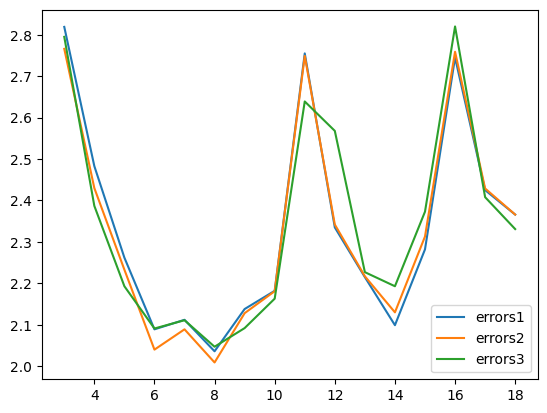

In [23]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.arange(3, 19)

errors1 = merged_df['test_rmse_x'].values
errors2 = merged_df['test_rmse_y'].values
errors3 = merged_df['test_rmse'].values

plt.plot(rng, errors1, label = "errors1")
plt.plot(rng, errors2, label = "errors2")
plt.plot(rng, errors3, label = "errors3")

plt.legend()
plt.show()

In [5]:
new_errors = [2.762, 2.618, 2.352, 2.410, 2.785, 2.765, 1.995, 3.070, 2.038, 3.102, 2.068, 2.048, 2.088, 2.079, 3, 3]


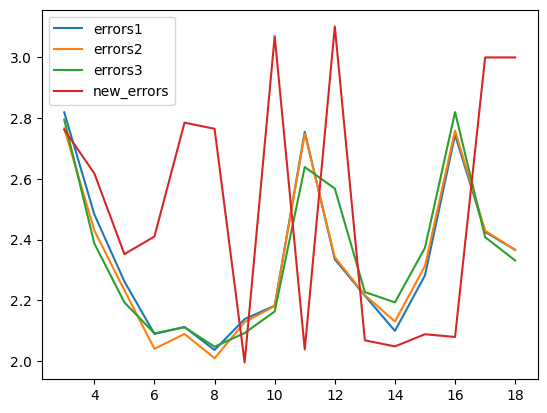

In [11]:
import matplotlib.pyplot as plt
import numpy as np
rng = np.arange(3, 19)

errors1 = merged_df['test_rmse_x'].values
errors2 = merged_df['test_rmse_y'].values
errors3 = merged_df['test_rmse'].values

plt.plot(rng, errors1, label = "errors1")
plt.plot(rng, errors2, label = "errors2")
plt.plot(rng, errors3, label = "errors3")
plt.plot(rng, new_errors, label = "new_errors")

plt.legend()
plt.show()

In [5]:
import pandas as pd
import os
project_root = "U:/ML_project/Bargh_ML"
csv_semi_processed_path = os.path.join(project_root, "data", "processed", f"semi_processed.csv")
df = pd.read_csv(csv_semi_processed_path, encoding='utf-8')

In [6]:
df.head()

,id,name,code,date,hour,temperature,humidity,dew,apparent_temperature,precipitation,...,temperature_with_1_delay,temperature_with_5_delay,humidity_with_1_delay,humidity_with_5_delay,dew_with_1_delay,dew_with_5_delay,surface_pressure_with_1_delay,surface_pressure_with_5_delay,generation_with_24_delay,interval_id
0,104,پرند,G16,2021-03-23,6,18.328000,29.0,-0.026892,12.705196,0.0,...,16.428000,14.328,32.0,35.0,-0.323926,-0.942513,892.5256,891.10114,99.218530,NaN
1,104,پرند,G14,2021-03-23,6,18.328000,29.0,-0.026892,12.705196,0.0,...,16.428000,14.328,32.0,35.0,-0.323926,-0.942513,892.5256,891.10114,109.573488,NaN
2,104,پرند,G14,2021-03-23,7,19.627998,29.0,1.096538,14.612114,0.0,...,18.328000,13.778,29.0,36.0,-0.026892,-1.044726,893.0706,891.50470,110.059087,NaN
3,104,پرند,G16,2021-03-23,7,19.627998,29.0,1.096538,14.612114,0.0,...,18.328000,13.778,29.0,36.0,-0.026892,-1.044726,893.0706,891.50470,99.714247,NaN
4,104,پرند,G16,2021-03-23,8,20.627998,28.0,1.469439,16.130455,0.0,...,19.627998,13.628,29.0,37.0,1.096538,-0.803171,892.6758,891.79870,98.095581,NaN


In [7]:
df.columns

Index(['id', 'name', 'code', 'date', 'hour', 'temperature', 'humidity', 'dew',
       'apparent_temperature', 'precipitation', 'rain', 'snow',
       'surface_pressure', 'evapotransporation', 'wind_speed',
       'wind_direction', 'value', 'forecast', 'generation', 'declare',
       'status', 'require', 'datetime', 'season', 'day_of_week', 'month',
       'is_good_peak', 'temperature_with_1_delay', 'temperature_with_5_delay',
       'humidity_with_1_delay', 'humidity_with_5_delay', 'dew_with_1_delay',
       'dew_with_5_delay', 'surface_pressure_with_1_delay',
       'surface_pressure_with_5_delay', 'generation_with_24_delay',
       'interval_id'],
      dtype='object')

In [8]:
df['code'].unique()

array(['G16', 'G14', 'G12', 'G13', 'G11', 'G15', 'S1', 'S2', 'S3'],
      dtype=object)